In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 设置绘图风格
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.dpi'] = 100

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. 数据加载

In [24]:
# 加载数据
train_path = '../DataSplit/TrainTest/Train.csv'
test_path = '../DataSplit/TrainTest/Test.csv'

df_train = pd.read_csv(train_path, parse_dates=['time'])
df_test = pd.read_csv(test_path, parse_dates=['time'])

print(f"训练集: {df_train.shape[0]} 条记录, {df_train['id'].nunique()} 个受试者")
print(f"测试集: {df_test.shape[0]} 条记录, {df_test['id'].nunique()} 个受试者")
df_train.head()

训练集: 83253 条记录, 158 个受试者
测试集: 11376 条记录, 158 个受试者


,id,time,gl,age,bmi
0,3,2012-01-01 00:00:00,89.539216,61.0,33.8
1,3,2012-01-01 00:05:00,90.070728,61.0,33.8
2,3,2012-01-01 00:10:00,90.366300,61.0,33.8
3,3,2012-01-01 00:15:00,90.450442,61.0,33.8
4,3,2012-01-01 00:20:00,90.347662,61.0,33.8


## 2. 特征构造模块

### 特征类别:
- **基础特征**: 历史血糖序列、Age、BMI
- **统计特征**: 均值、标准差、最大值、最小值、变化率等
- **时间特征**: 小时、是否夜间等
- **衍生特征**: 一阶差分、二阶差分、滑动平均等

In [25]:
# ============================================================
# 特征构造函数 - 可在此处添加新特征
# ============================================================

class FeatureExtractor:
    """
    特征提取器 - 可灵活配置需要提取的特征
    
    使用方法:
        extractor = FeatureExtractor(n_past=12)
        extractor.enable_features(['stat', 'time', 'diff'])  # 启用特征组
        features = extractor.extract(gl_window, age, bmi, hour)
    """
    
    def __init__(self, n_past=12):
        self.n_past = n_past
        self.enabled_features = set(['base'])  # 默认启用基础特征
        
        # 特征组定义
        self.feature_groups = {
            'base': ['gl_sequence', 'age', 'bmi'],
            'stat': ['gl_mean', 'gl_std', 'gl_min', 'gl_max', 'gl_range', 'gl_cv'],
            'time': ['hour', 'is_night', 'hour_sin', 'hour_cos'],
            'diff': ['gl_diff_mean', 'gl_diff_std', 'gl_diff2_mean'],
            'trend': ['gl_slope', 'gl_last_change', 'gl_momentum'],
            'quantile': ['gl_q25', 'gl_q75', 'gl_iqr'],
        }
    
    def enable_features(self, groups):
        """启用指定的特征组"""
        if isinstance(groups, str):
            groups = [groups]
        self.enabled_features = set(['base'])  # 基础特征始终启用
        for g in groups:
            if g in self.feature_groups:
                self.enabled_features.add(g)
    
    def enable_all(self):
        """启用所有特征"""
        self.enabled_features = set(self.feature_groups.keys())
    
    def get_feature_names(self):
        """获取当前启用的所有特征名称"""
        names = []
        for group in self.enabled_features:
            if group == 'base':
                names.extend([f'gl_t-{i}' for i in range(self.n_past, 0, -1)])
                names.extend(['age', 'bmi'])
            else:
                names.extend(self.feature_groups[group])
        return names
    
    def get_seq_features_count(self):
        """获取序列特征数量 (用于LSTM输入)"""
        return self.n_past
    
    def get_static_features_count(self):
        """获取静态特征数量"""
        count = 2  # age, bmi
        for group in self.enabled_features:
            if group != 'base':
                count += len(self.feature_groups[group])
        return count
    
    def extract(self, gl_window, age, bmi, hour):
        """
        提取特征
        
        参数:
            gl_window: 历史血糖窗口 (长度为 n_past)
            age: 年龄
            bmi: BMI
            hour: 当前小时 (0-23)
        
        返回:
            seq_features: 序列特征 (用于LSTM)
            static_features: 静态特征
        """
        seq_features = gl_window.copy()
        static_features = [age, bmi]
        
        # 统计特征
        if 'stat' in self.enabled_features:
            gl_mean = np.mean(gl_window)
            gl_std = np.std(gl_window)
            gl_min = np.min(gl_window)
            gl_max = np.max(gl_window)
            gl_range = gl_max - gl_min
            gl_cv = gl_std / gl_mean if gl_mean != 0 else 0  # 变异系数
            static_features.extend([gl_mean, gl_std, gl_min, gl_max, gl_range, gl_cv])
        
        # 时间特征
        if 'time' in self.enabled_features:
            is_night = 1 if (hour >= 22 or hour <= 6) else 0
            hour_sin = np.sin(2 * np.pi * hour / 24)
            hour_cos = np.cos(2 * np.pi * hour / 24)
            static_features.extend([hour, is_night, hour_sin, hour_cos])
        
        # 差分特征
        if 'diff' in self.enabled_features:
            gl_diff = np.diff(gl_window)  # 一阶差分
            gl_diff2 = np.diff(gl_diff)   # 二阶差分
            gl_diff_mean = np.mean(gl_diff)
            gl_diff_std = np.std(gl_diff)
            gl_diff2_mean = np.mean(gl_diff2) if len(gl_diff2) > 0 else 0
            static_features.extend([gl_diff_mean, gl_diff_std, gl_diff2_mean])
        
        # 趋势特征
        if 'trend' in self.enabled_features:
            # 线性回归斜率
            x = np.arange(len(gl_window))
            slope, _, _, _, _ = stats.linregress(x, gl_window)
            # 最近变化
            gl_last_change = gl_window[-1] - gl_window[-2] if len(gl_window) >= 2 else 0
            # 动量 (最近3点的平均变化)
            gl_momentum = np.mean(np.diff(gl_window[-4:])) if len(gl_window) >= 4 else 0
            static_features.extend([slope, gl_last_change, gl_momentum])
        
        # 分位数特征
        if 'quantile' in self.enabled_features:
            gl_q25 = np.percentile(gl_window, 25)
            gl_q75 = np.percentile(gl_window, 75)
            gl_iqr = gl_q75 - gl_q25
            static_features.extend([gl_q25, gl_q75, gl_iqr])
        
        return np.array(seq_features), np.array(static_features)

# 测试特征提取器
extractor = FeatureExtractor(n_past=12)
extractor.enable_all()
print(f"特征组: {list(extractor.feature_groups.keys())}")
print(f"序列特征数: {extractor.get_seq_features_count()}")
print(f"静态特征数: {extractor.get_static_features_count()}")

特征组: ['base', 'stat', 'time', 'diff', 'trend', 'quantile']
序列特征数: 12
静态特征数: 21


In [26]:
def create_feature_dataset(data, extractor, n_past, prediction_horizon=1):
    """
    使用特征提取器创建数据集
    
    返回:
        X_seq: 序列特征 (N, n_past)
        X_static: 静态特征 (N, n_static)
        y: 目标值 (N,)
    """
    X_seq, X_static, y = [], [], []
    
    for subject_id, group in data.groupby('id'):
        group = group.sort_values('time')
        gl_values = group['gl'].values
        times = group['time'].values
        age = group['age'].iloc[0]
        bmi = group['bmi'].iloc[0]
        
        if len(gl_values) < n_past + prediction_horizon:
            continue
        
        for i in range(n_past, len(gl_values) - prediction_horizon + 1):
            gl_window = gl_values[i-n_past:i]
            hour = pd.Timestamp(times[i]).hour
            
            seq_feat, static_feat = extractor.extract(gl_window, age, bmi, hour)
            
            X_seq.append(seq_feat)
            X_static.append(static_feat)
            y.append(gl_values[i + prediction_horizon - 1])
    
    return np.array(X_seq), np.array(X_static), np.array(y)

# 参数设置
N_PAST = 12
PREDICTION_HORIZON = 6

print(f"参数: N_PAST={N_PAST}, HORIZON={PREDICTION_HORIZON}")

参数: N_PAST=12, HORIZON=6


## 3. 特征相关性分析

In [27]:
# 使用全部特征创建数据集用于分析
extractor_full = FeatureExtractor(n_past=N_PAST)
extractor_full.enable_all()

X_seq_train, X_static_train, y_train = create_feature_dataset(
    df_train, extractor_full, N_PAST, PREDICTION_HORIZON
)

print(f"序列特征形状: {X_seq_train.shape}")
print(f"静态特征形状: {X_static_train.shape}")
print(f"目标值形状: {y_train.shape}")

序列特征形状: (80567, 12)
静态特征形状: (80567, 21)
目标值形状: (80567,)


In [28]:
# 构建特征 DataFrame 用于分析
feature_names = extractor_full.get_feature_names()
seq_names = feature_names[:N_PAST]
static_names = feature_names[N_PAST:]

# 合并所有特征
X_all = np.hstack([X_seq_train, X_static_train])
df_features = pd.DataFrame(X_all, columns=feature_names)
df_features['target'] = y_train

print(f"特征数量: {len(feature_names)}")
print(f"静态特征: {static_names}")

特征数量: 33
静态特征: ['gl_t-3', 'gl_t-2', 'gl_t-1', 'age', 'bmi', 'gl_mean', 'gl_std', 'gl_min', 'gl_max', 'gl_range', 'gl_cv', 'hour', 'is_night', 'hour_sin', 'hour_cos', 'gl_q25', 'gl_q75', 'gl_iqr', 'gl_diff_mean', 'gl_diff_std', 'gl_diff2_mean']


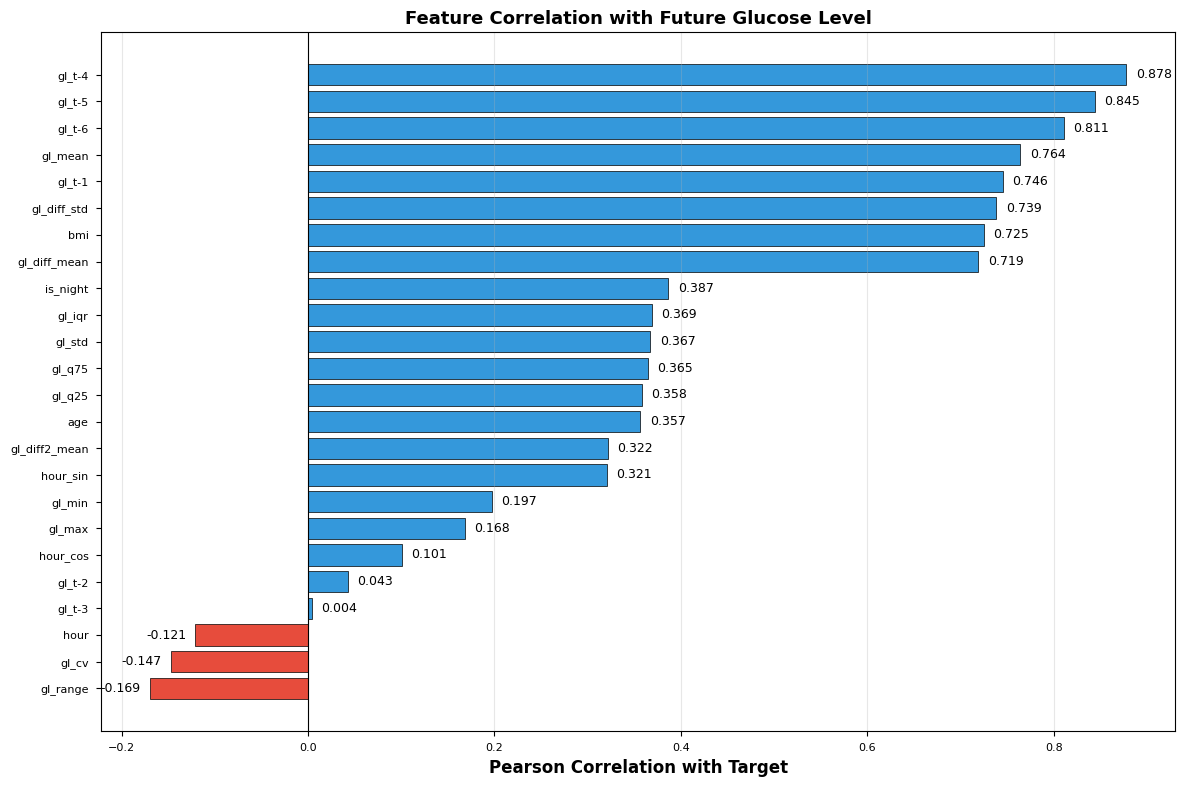

In [29]:
# --- 特征与目标的相关性 ---
correlations = df_features.corr()['target'].drop('target').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))

# 只显示静态特征和最近几个时间点的相关性
selected_features = list(static_names) + [f'gl_t-{i}' for i in range(1, 7)]
selected_corr = correlations[correlations.index.isin(selected_features)].sort_values(ascending=True)

colors = ['#e74c3c' if v < 0 else '#3498db' for v in selected_corr.values]
bars = ax.barh(selected_corr.index, selected_corr.values, color=colors, edgecolor='black', linewidth=0.5)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Target', fontweight='bold')
ax.set_title('Feature Correlation with Future Glucose Level', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 添加数值标签
for bar, val in zip(bars, selected_corr.values):
    ax.text(val + 0.01 if val >= 0 else val - 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

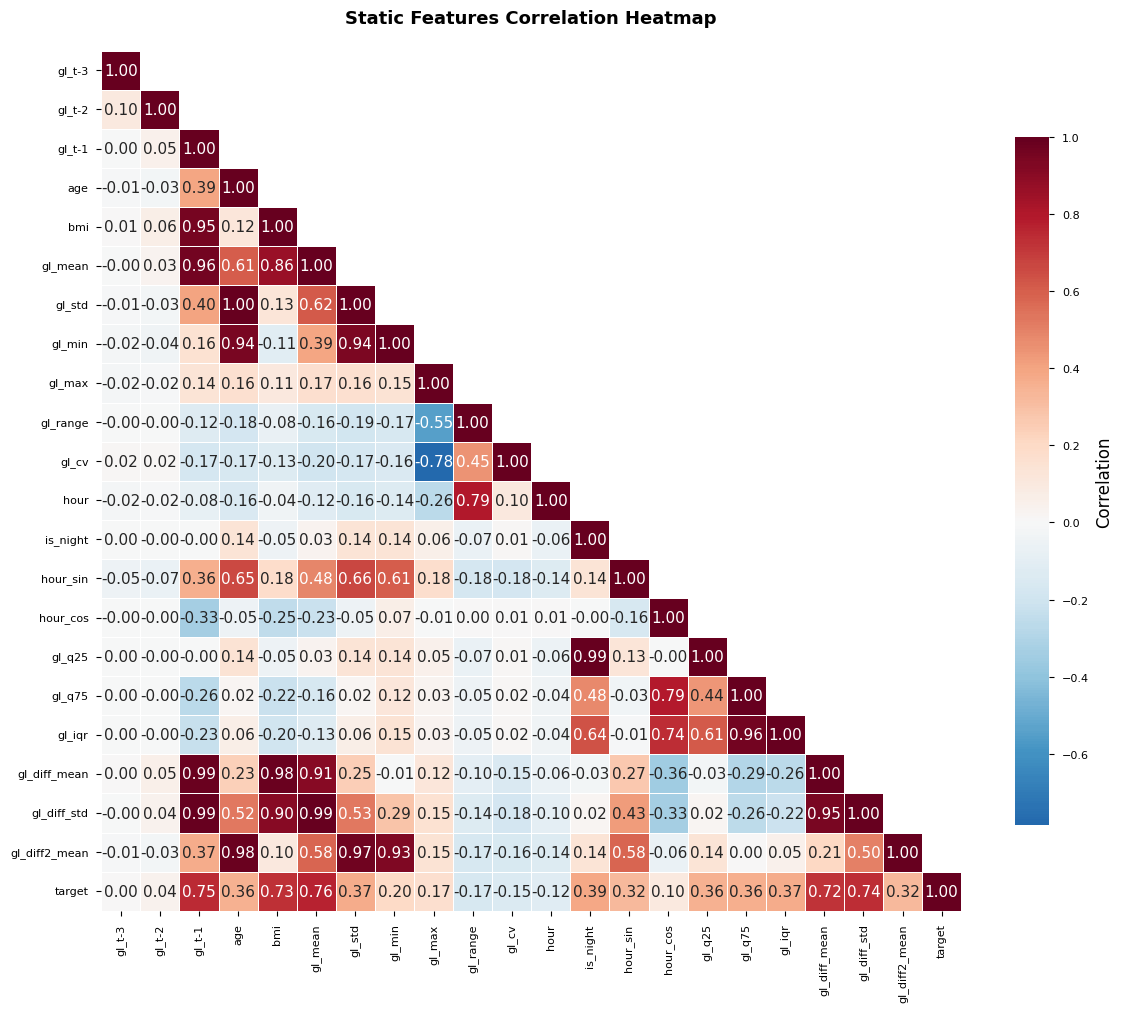

In [30]:
# --- 静态特征相关性热力图 ---
static_cols = static_names + ['target']
corr_matrix = df_features[static_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})

ax.set_title('Static Features Correlation Heatmap', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

📊 特征冗余分析: 静态特征与序列均值的相关性
⚠️ 高相关性意味着该特征对 LSTM 来说是冗余的
      feature  corr_with_sequence  corr_with_target redundancy
       gl_t-1            0.992852          0.745843        高冗余
  gl_diff_std            0.984093          0.738503        高冗余
 gl_diff_mean            0.976779          0.719351        高冗余
      gl_mean            0.958699          0.764388        高冗余
          bmi            0.942211          0.725095        高冗余
       gl_std            0.409925          0.367312        低冗余
          age            0.401179          0.356700        低冗余
gl_diff2_mean            0.378569          0.322028        低冗余
     hour_sin            0.366760          0.320668        低冗余
     hour_cos            0.351308          0.100644        低冗余
       gl_q75            0.235959          0.364910        低冗余
       gl_iqr            0.182465          0.369329        低冗余
        gl_cv            0.166538         -0.147028        低冗余
       gl_min            0.162856          0.196866        低冗余
    

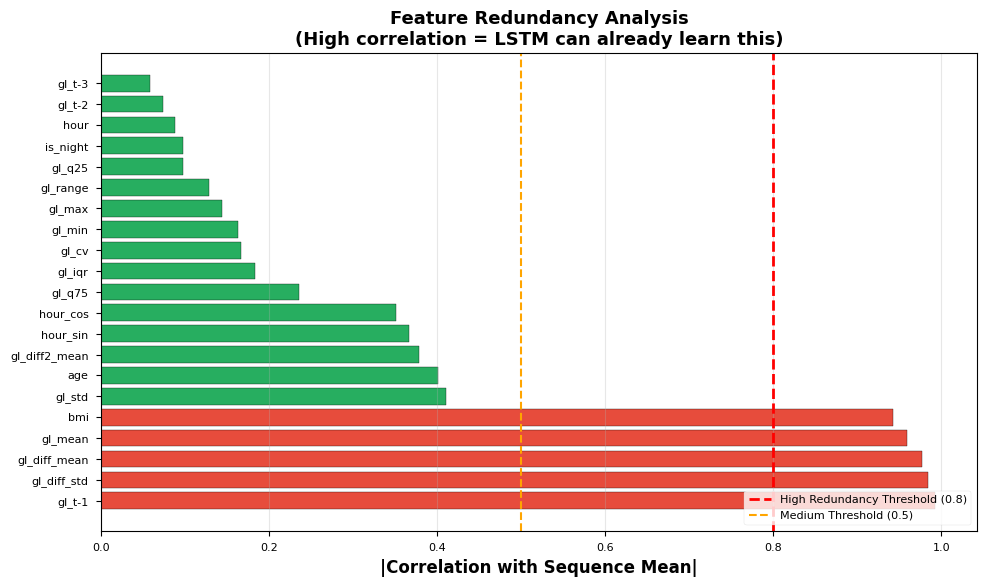


💡 结论: gl_mean, gl_min, gl_max, gl_q25, gl_q75 等统计特征与序列高度相关
   LSTM 已能从序列中学习这些模式，手动添加反而造成冗余


In [31]:
# --- 特征冗余分析: 检查哪些特征与序列特征高度相关 ---
print("="*60)
print("📊 特征冗余分析: 静态特征与序列均值的相关性")
print("="*60)
print("⚠️ 高相关性意味着该特征对 LSTM 来说是冗余的")
print("="*60)

# 计算每个静态特征与序列均值的相关性
seq_mean = df_features[[f'gl_t-{i}' for i in range(1, N_PAST+1)]].mean(axis=1)

redundancy_analysis = []
for feat in static_names:
    if feat in df_features.columns:
        corr_with_seq = df_features[feat].corr(seq_mean)
        corr_with_target = df_features[feat].corr(df_features['target'])
        redundancy_analysis.append({
            'feature': feat,
            'corr_with_sequence': abs(corr_with_seq),
            'corr_with_target': corr_with_target,
            'redundancy': '高冗余' if abs(corr_with_seq) > 0.8 else ('中等' if abs(corr_with_seq) > 0.5 else '低冗余')
        })

df_redundancy = pd.DataFrame(redundancy_analysis).sort_values('corr_with_sequence', ascending=False)
print(df_redundancy.to_string(index=False))

# 可视化
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if r == '高冗余' else ('#f39c12' if r == '中等' else '#27ae60') 
          for r in df_redundancy['redundancy']]
bars = ax.barh(df_redundancy['feature'], df_redundancy['corr_with_sequence'], color=colors, edgecolor='black')

ax.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='High Redundancy Threshold (0.8)')
ax.axvline(x=0.5, color='orange', linestyle='--', linewidth=1.5, label='Medium Threshold (0.5)')
ax.set_xlabel('|Correlation with Sequence Mean|', fontweight='bold')
ax.set_title('Feature Redundancy Analysis\n(High correlation = LSTM can already learn this)', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 结论: gl_mean, gl_min, gl_max, gl_q25, gl_q75 等统计特征与序列高度相关")
print("   LSTM 已能从序列中学习这些模式，手动添加反而造成冗余")

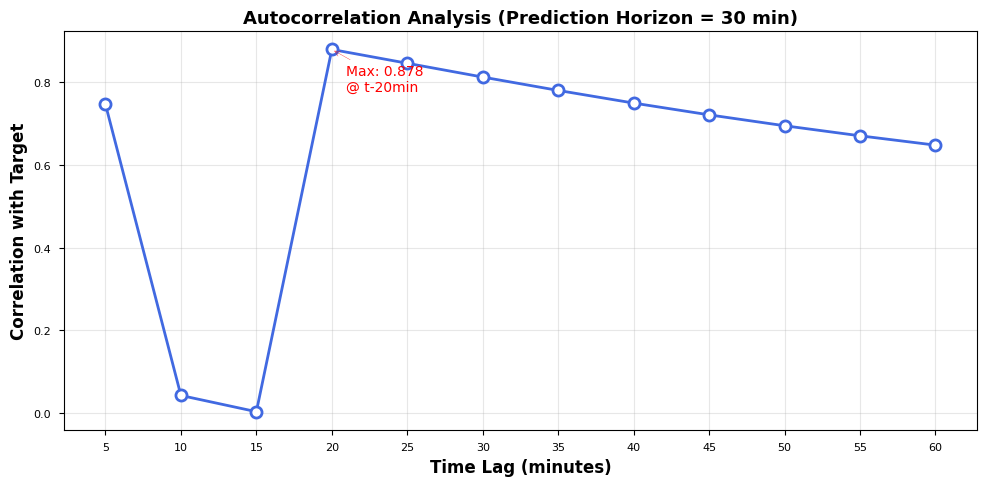

In [32]:
# --- 时间滞后相关性分析 ---
# 分析不同历史时间点与目标的相关性
lag_corrs = []
for i in range(1, N_PAST + 1):
    col_name = f'gl_t-{i}'
    corr = df_features[col_name].corr(df_features['target'])
    lag_corrs.append({'lag': i, 'lag_minutes': i * 5, 'correlation': corr})

df_lag = pd.DataFrame(lag_corrs)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_lag['lag_minutes'], df_lag['correlation'], 'o-', color='royalblue', 
        linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)

ax.set_xlabel('Time Lag (minutes)', fontweight='bold')
ax.set_ylabel('Correlation with Target', fontweight='bold')
ax.set_title(f'Autocorrelation Analysis (Prediction Horizon = {PREDICTION_HORIZON*5} min)', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(df_lag['lag_minutes'])

# 标注最高相关性
max_idx = df_lag['correlation'].idxmax()
ax.annotate(f'Max: {df_lag.loc[max_idx, "correlation"]:.3f}\n@ t-{df_lag.loc[max_idx, "lag_minutes"]}min',
            xy=(df_lag.loc[max_idx, 'lag_minutes'], df_lag.loc[max_idx, 'correlation']),
            xytext=(10, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

plt.tight_layout()
plt.show()

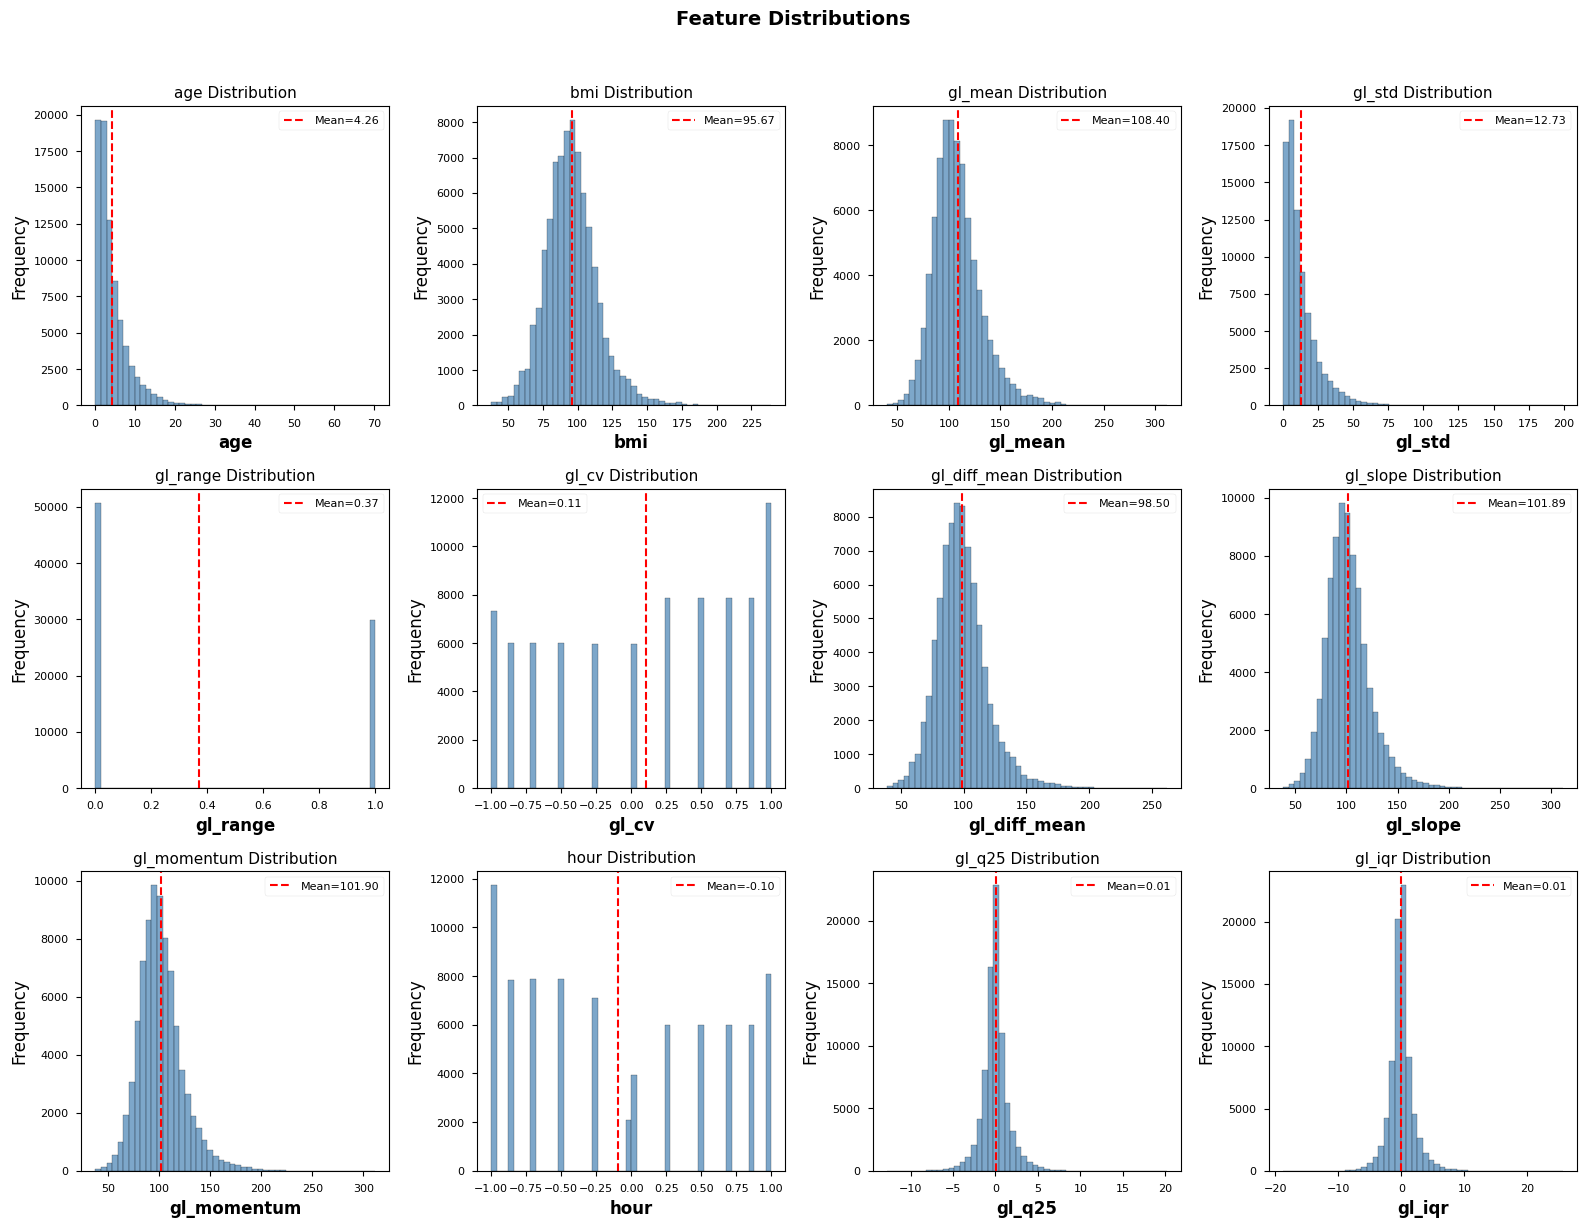

In [33]:
# --- 特征分布可视化 ---
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

plot_features = ['age', 'bmi', 'gl_mean', 'gl_std', 'gl_range', 'gl_cv',
                 'gl_diff_mean', 'gl_slope', 'gl_momentum', 'hour', 'gl_q25', 'gl_iqr']

for i, feat in enumerate(plot_features):
    if feat in df_features.columns:
        ax = axes[i]
        ax.hist(df_features[feat], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
        ax.set_xlabel(feat, fontweight='bold')
        ax.set_ylabel('Frequency')
        ax.set_title(f'{feat} Distribution', fontsize=11)
        
        # 添加统计信息
        mean_val = df_features[feat].mean()
        std_val = df_features[feat].std()
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean_val:.2f}')
        ax.legend(fontsize=8)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. LSTM 模型定义

In [34]:
# --- PyTorch Dataset ---
class FeatureDataset(Dataset):
    def __init__(self, X_seq, X_static, y):
        self.X_seq = torch.FloatTensor(X_seq).unsqueeze(2)  # (N, seq_len, 1)
        self.X_static = torch.FloatTensor(X_static)          # (N, n_static)
        self.y = torch.FloatTensor(y).unsqueeze(1)           # (N, 1)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_static[idx], self.y[idx]

# --- LSTM 模型 ---
class FeatureLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, static_len):
        super(FeatureLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size + static_len, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x_seq, x_static):
        h0 = torch.zeros(self.num_layers, x_seq.size(0), self.hidden_size).to(x_seq.device)
        c0 = torch.zeros(self.num_layers, x_seq.size(0), self.hidden_size).to(x_seq.device)
        
        out, _ = self.lstm(x_seq, (h0, c0))
        out = out[:, -1, :]
        out = torch.cat((out, x_static), dim=1)
        out = self.dropout(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [35]:
def calculate_metrics(y_true, y_pred):
    """计算评估指标"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    rmspe = np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask]))) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'RMSPE': rmspe}

def train_and_evaluate(extractor, df_train, df_test, n_past, horizon, 
                       hidden_size=32, num_epochs=30, batch_size=64, lr=0.001, verbose=True):
    """
    训练并评估模型
    
    返回:
        metrics: 评估指标字典
        model: 训练好的模型
        history: 训练历史
    """
    # 创建数据集
    X_seq_train, X_static_train, y_train = create_feature_dataset(df_train, extractor, n_past, horizon)
    X_seq_test, X_static_test, y_test = create_feature_dataset(df_test, extractor, n_past, horizon)
    
    # 标准化
    scaler_seq = StandardScaler()
    scaler_static = StandardScaler()
    
    X_seq_train_scaled = scaler_seq.fit_transform(X_seq_train)
    X_seq_test_scaled = scaler_seq.transform(X_seq_test)
    
    X_static_train_scaled = scaler_static.fit_transform(X_static_train)
    X_static_test_scaled = scaler_static.transform(X_static_test)
    
    # DataLoader
    train_dataset = FeatureDataset(X_seq_train_scaled, X_static_train_scaled, y_train)
    test_dataset = FeatureDataset(X_seq_test_scaled, X_static_test_scaled, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # 模型
    static_len = X_static_train.shape[1]
    model = FeatureLSTM(1, hidden_size, 1, static_len).to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 训练
    train_losses, val_losses = [], []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for x_seq, x_static, y in train_loader:
            x_seq, x_static, y = x_seq.to(device), x_static.to(device), y.to(device)
            
            optimizer.zero_grad()
            outputs = model(x_seq, x_static)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        train_losses.append(running_loss / len(train_loader))
        
        # 验证
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_seq, x_static, y in test_loader:
                x_seq, x_static, y = x_seq.to(device), x_static.to(device), y.to(device)
                outputs = model(x_seq, x_static)
                val_loss += criterion(outputs, y).item()
        
        val_losses.append(val_loss / len(test_loader))
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    
    # 评估
    model.eval()
    y_pred_list = []
    with torch.no_grad():
        for x_seq, x_static, _ in test_loader:
            x_seq, x_static = x_seq.to(device), x_static.to(device)
            outputs = model(x_seq, x_static)
            y_pred_list.extend(outputs.cpu().numpy())
    
    y_pred = np.array(y_pred_list).flatten()
    metrics = calculate_metrics(y_test, y_pred)
    
    return metrics, model, {'train_loss': train_losses, 'val_loss': val_losses}, y_test, y_pred

## 5. 消融实验 - 特征组合对比

In [36]:
# ============================================================
# 消融实验配置 - 优化后的特征组合
# ============================================================

# 注意: LSTM 本身已经能从序列中学习统计模式
# 所以添加 stat 特征可能造成冗余，反而降低效果
# 更有价值的是 LSTM 难以直接学到的信息

ablation_configs = {
    'Baseline (GL + Age + BMI)': [],                           # 只有基础特征
    '+ Time Features': ['time'],                               # 时间节律信息
    '+ Trend Features': ['trend'],                             # 趋势信息 (斜率、动量)
    '+ Diff Features': ['diff'],                               # 变化率信息
    '+ Time + Trend': ['time', 'trend'],                       # 时间 + 趋势
    '+ Time + Diff': ['time', 'diff'],                         # 时间 + 差分
    '+ Trend + Diff': ['trend', 'diff'],                       # 趋势 + 差分
    '+ Statistical Features': ['stat'],                        # 统计特征 (可能冗余)
    'All Features': ['stat', 'time', 'diff', 'trend', 'quantile'],  # 全部特征
}

print("消融实验配置:")
print("="*60)
print("💡 说明: LSTM 已能从序列学习统计模式，stat 特征可能冗余")
print("="*60)
for name, groups in ablation_configs.items():
    print(f"  - {name}: {groups if groups else 'base only'}")

消融实验配置:
💡 说明: LSTM 已能从序列学习统计模式，stat 特征可能冗余
  - Baseline (GL + Age + BMI): base only
  - + Time Features: ['time']
  - + Trend Features: ['trend']
  - + Diff Features: ['diff']
  - + Time + Trend: ['time', 'trend']
  - + Time + Diff: ['time', 'diff']
  - + Trend + Diff: ['trend', 'diff']
  - + Statistical Features: ['stat']
  - All Features: ['stat', 'time', 'diff', 'trend', 'quantile']


In [37]:
# --- 运行消融实验 (多次运行取平均以减少随机性) ---
NUM_RUNS = 3  # 每个配置运行多次取平均

ablation_results = []

print("="*70)
print(f"开始消融实验 (每个配置运行 {NUM_RUNS} 次取平均)...")
print("="*70)

for exp_name, feature_groups in ablation_configs.items():
    print(f"\n▶ {exp_name}")
    
    # 配置特征提取器
    extractor = FeatureExtractor(n_past=N_PAST)
    if feature_groups:
        extractor.enable_features(feature_groups)
    
    # 多次运行取平均
    run_metrics = []
    for run in range(NUM_RUNS):
        metrics, model, history, y_true, y_pred = train_and_evaluate(
            extractor, df_train, df_test, N_PAST, PREDICTION_HORIZON,
            num_epochs=30, verbose=False
        )
        run_metrics.append(metrics)
    
    # 计算平均值和标准差
    avg_metrics = {k: np.mean([m[k] for m in run_metrics]) for k in run_metrics[0].keys()}
    std_metrics = {k: np.std([m[k] for m in run_metrics]) for k in run_metrics[0].keys()}
    
    result = {
        'experiment': exp_name,
        'features': feature_groups,
        'n_static_features': extractor.get_static_features_count(),
        **avg_metrics,
        'MAE_std': std_metrics['MAE'],
        'RMSE_std': std_metrics['RMSE'],
    }
    ablation_results.append(result)
    
    print(f"   Static Features: {result['n_static_features']}")
    print(f"   MAE: {avg_metrics['MAE']:.4f} ± {std_metrics['MAE']:.4f}")
    print(f"   RMSE: {avg_metrics['RMSE']:.4f} ± {std_metrics['RMSE']:.4f}")

print("\n" + "="*70)
print("消融实验完成!")
print("="*70)

开始消融实验 (每个配置运行 3 次取平均)...

▶ Baseline (GL + Age + BMI)
   Static Features: 2
   MAE: 3.3172 ± 0.1475
   RMSE: 4.6809 ± 0.2227

▶ + Time Features
   Static Features: 6
   MAE: 3.3011 ± 0.0470
   RMSE: 4.6545 ± 0.0387

▶ + Trend Features
   Static Features: 5
   MAE: 3.3209 ± 0.1103
   RMSE: 4.7312 ± 0.0759

▶ + Diff Features
   Static Features: 5
   MAE: 3.2046 ± 0.0919
   RMSE: 4.5239 ± 0.0703

▶ + Time + Trend
   Static Features: 9
   MAE: 3.3149 ± 0.0844
   RMSE: 4.6628 ± 0.1696

▶ + Time + Diff
   Static Features: 9
   MAE: 3.3479 ± 0.0887
   RMSE: 4.7079 ± 0.1250

▶ + Trend + Diff
   Static Features: 8
   MAE: 3.2289 ± 0.0878
   RMSE: 4.6960 ± 0.1914

▶ + Statistical Features
   Static Features: 8
   MAE: 3.5793 ± 0.3792
   RMSE: 5.0221 ± 0.6544

▶ All Features
   Static Features: 21
   MAE: 3.5636 ± 0.0795
   RMSE: 5.0503 ± 0.0713

消融实验完成!


In [38]:
# --- 消融实验结果汇总表 ---
df_ablation = pd.DataFrame(ablation_results)
df_ablation = df_ablation.sort_values('MAE')

print("\n" + "="*80)
print("📊 消融实验结果汇总 (按 MAE 排序)")
print("="*80)
print(df_ablation[['experiment', 'n_static_features', 'MAE', 'RMSE', 'MAPE', 'RMSPE']].to_string(index=False))
print("="*80)


📊 消融实验结果汇总 (按 MAE 排序)
               experiment  n_static_features      MAE     RMSE     MAPE    RMSPE
          + Diff Features                  5 3.204597 4.523947 2.979193 4.078117
           + Trend + Diff                  8 3.228895 4.696008 2.948249 4.113351
          + Time Features                  6 3.301093 4.654463 3.051406 4.130254
           + Time + Trend                  9 3.314941 4.662794 3.090314 4.204833
Baseline (GL + Age + BMI)                  2 3.317220 4.680898 3.047113 4.142372
         + Trend Features                  5 3.320932 4.731205 3.068506 4.211746
            + Time + Diff                  9 3.347852 4.707915 3.121463 4.243950
             All Features                 21 3.563550 5.050347 3.294220 4.464462
   + Statistical Features                  8 3.579335 5.022120 3.291528 4.410033


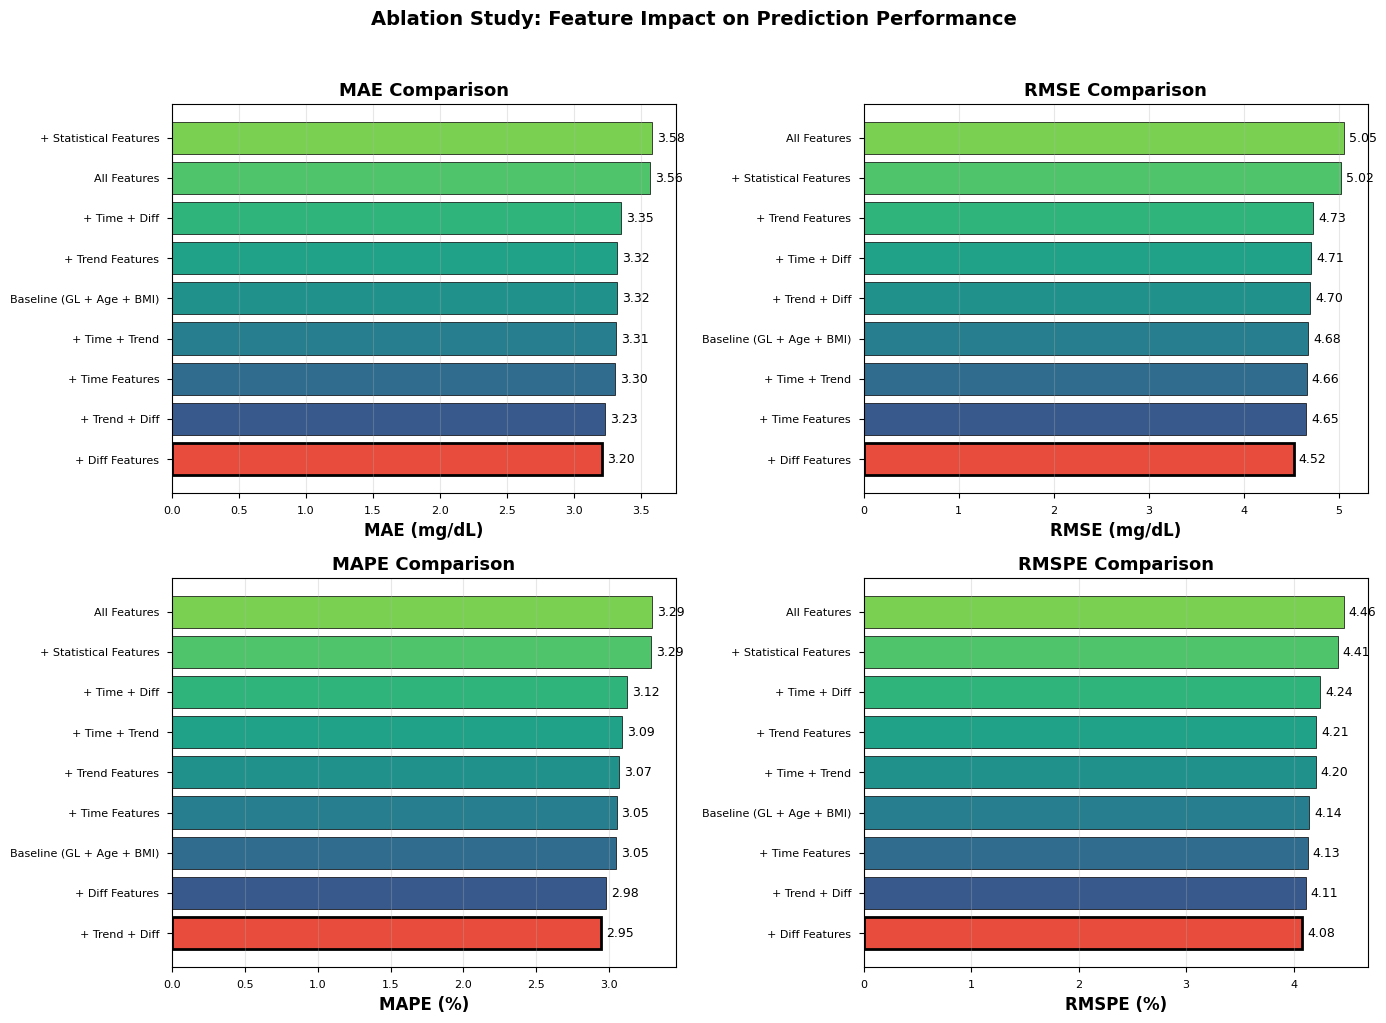

In [39]:
# --- 消融实验可视化 ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['MAE', 'RMSE', 'MAPE', 'RMSPE']
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(df_ablation)))

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i // 2, i % 2]
    
    # 按该指标排序
    df_sorted = df_ablation.sort_values(metric)
    
    bars = ax.barh(df_sorted['experiment'], df_sorted[metric], 
                   color=colors, edgecolor='black', linewidth=0.5)
    
    # 高亮最佳结果
    best_idx = df_sorted[metric].idxmin()
    for j, (bar, exp) in enumerate(zip(bars, df_sorted['experiment'])):
        if df_sorted.loc[df_sorted['experiment'] == exp, metric].index[0] == best_idx:
            bar.set_color('#e74c3c')
            bar.set_edgecolor('black')
            bar.set_linewidth(2)
    
    unit = 'mg/dL' if metric in ['MAE', 'RMSE'] else '%'
    ax.set_xlabel(f'{metric} ({unit})', fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # 添加数值标签
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.01 * ax.get_xlim()[1], bar.get_y() + bar.get_height()/2,
                f'{width:.2f}', va='center', fontsize=9)

plt.suptitle('Ablation Study: Feature Impact on Prediction Performance', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

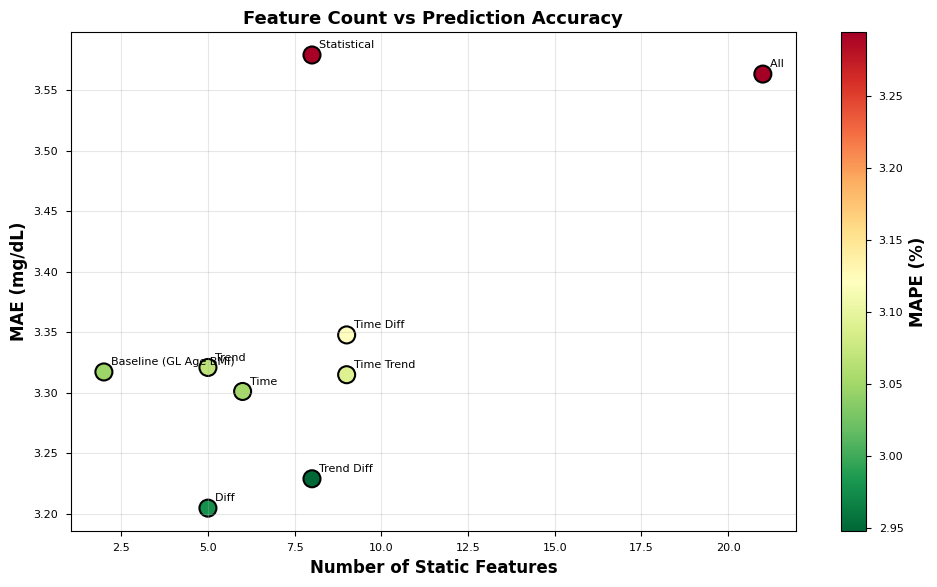

In [40]:
# --- 特征数量 vs 性能关系 ---
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df_ablation['n_static_features'], df_ablation['MAE'],
                     s=150, c=df_ablation['MAPE'], cmap='RdYlGn_r',
                     edgecolors='black', linewidth=1.5)

# 添加标签
for i, row in df_ablation.iterrows():
    ax.annotate(row['experiment'].replace('+ ', '').replace('Features', ''),
                (row['n_static_features'], row['MAE']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_xlabel('Number of Static Features', fontweight='bold')
ax.set_ylabel('MAE (mg/dL)', fontweight='bold')
ax.set_title('Feature Count vs Prediction Accuracy', fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('MAPE (%)', fontweight='bold')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 最佳特征组合详细分析

In [41]:
# --- 使用最佳特征组合重新训练并详细分析 ---
best_exp = df_ablation.loc[df_ablation['MAE'].idxmin()]
print(f"最佳特征组合: {best_exp['experiment']}")
print(f"特征组: {best_exp['features']}")

# 配置最佳特征提取器
best_extractor = FeatureExtractor(n_past=N_PAST)
if best_exp['features']:
    best_extractor.enable_features(best_exp['features'])

# 训练最佳模型
print("\n训练最佳模型...")
best_metrics, best_model, best_history, y_true_best, y_pred_best = train_and_evaluate(
    best_extractor, df_train, df_test, N_PAST, PREDICTION_HORIZON,
    num_epochs=50, verbose=True
)

最佳特征组合: + Diff Features
特征组: ['diff']

训练最佳模型...
Epoch [10/50], Train Loss: 59.2142, Val Loss: 43.5416
Epoch [20/50], Train Loss: 28.1287, Val Loss: 23.5035
Epoch [30/50], Train Loss: 25.5407, Val Loss: 20.8727
Epoch [40/50], Train Loss: 24.3472, Val Loss: 21.4050
Epoch [50/50], Train Loss: 23.7105, Val Loss: 19.3720


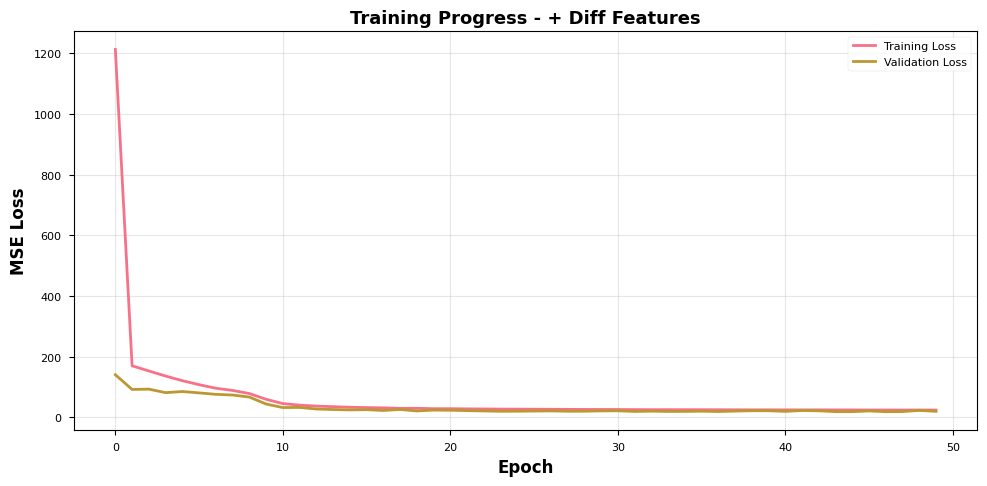

In [42]:
# --- 训练曲线 ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(best_history['train_loss'], label='Training Loss', linewidth=2)
ax.plot(best_history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('MSE Loss', fontweight='bold')
ax.set_title(f'Training Progress - {best_exp["experiment"]}', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

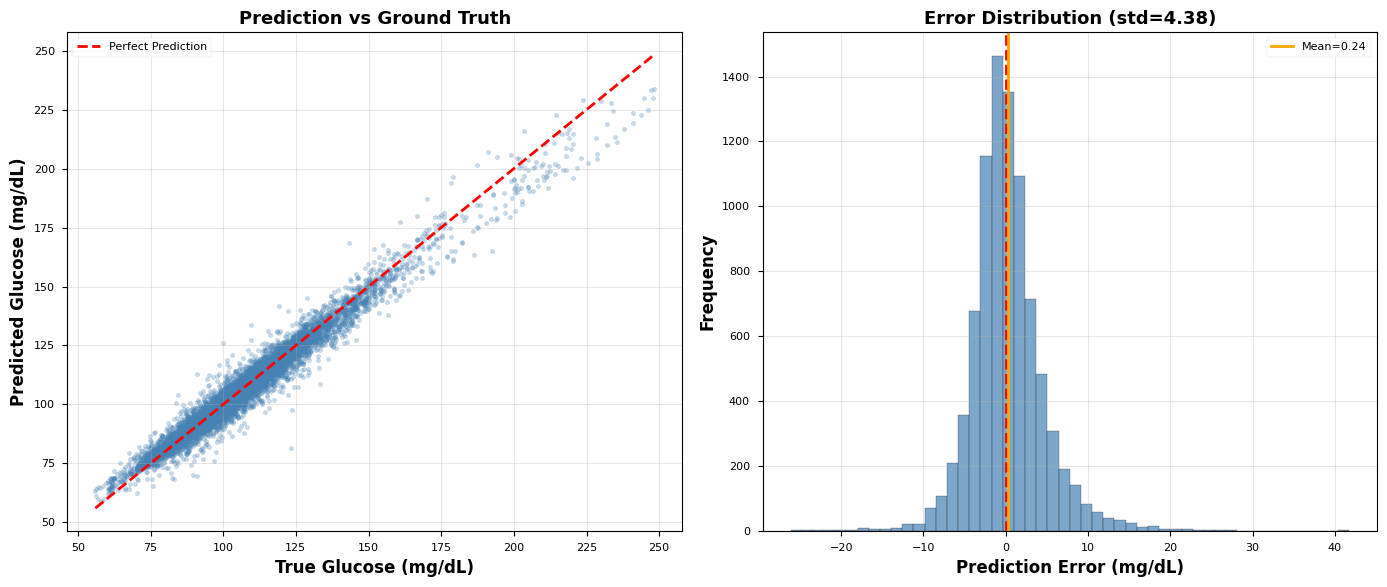

In [43]:
# --- 预测 vs 真实值散点图 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 散点图
ax1 = axes[0]
ax1.scatter(y_true_best, y_pred_best, alpha=0.3, s=10, color='steelblue')
ax1.plot([y_true_best.min(), y_true_best.max()], 
         [y_true_best.min(), y_true_best.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('True Glucose (mg/dL)', fontweight='bold')
ax1.set_ylabel('Predicted Glucose (mg/dL)', fontweight='bold')
ax1.set_title('Prediction vs Ground Truth', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 误差分布
ax2 = axes[1]
errors = y_true_best - y_pred_best
ax2.hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.axvline(x=np.mean(errors), color='orange', linestyle='-', linewidth=2, label=f'Mean={np.mean(errors):.2f}')
ax2.set_xlabel('Prediction Error (mg/dL)', fontweight='bold')
ax2.set_ylabel('Frequency', fontweight='bold')
ax2.set_title(f'Error Distribution (std={np.std(errors):.2f})', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

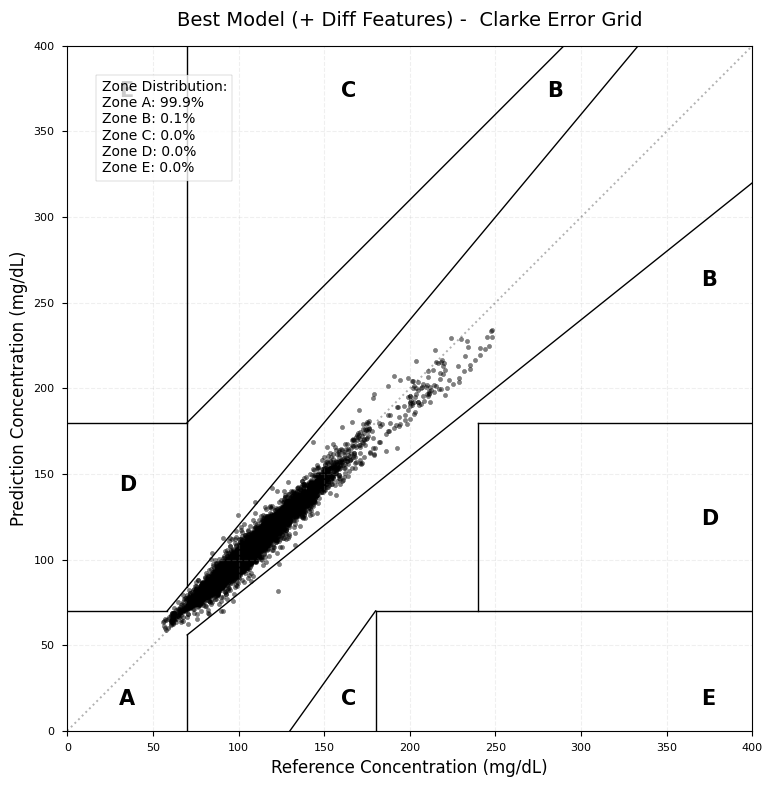


Clarke Error Grid 分布:
  Zone A: 99.88%
  Zone B: 0.12%
  Zone C: 0.00%
  Zone D: 0.00%
  Zone E: 0.00%
  A+B (临床安全): 100.00%


In [44]:
# --- Clarke Error Grid ---
import sys
import importlib
import os

utils_path = os.path.abspath('../../utils')
if utils_path not in sys.path:
    sys.path.append(utils_path)

import ceg_utils
importlib.reload(ceg_utils)

plt_obj, zones_pct = ceg_utils.clarke_error_grid(
    y_true_best, y_pred_best,
    title_string=f"Best Model ({best_exp['experiment']}) - "
)
plt_obj.show()

zones = ['A', 'B', 'C', 'D', 'E']
print("\nClarke Error Grid 分布:")
for z, p in zip(zones, zones_pct):
    print(f"  Zone {z}: {p:.2f}%")
print(f"  A+B (临床安全): {zones_pct[0] + zones_pct[1]:.2f}%")

## 7. 特征工程分析与结论

### 为什么添加特征反而效果变差？

1. **LSTM 的特征学习能力**: LSTM 本身就能从原始序列中学习到统计模式（均值、方差、趋势等），手动添加这些特征造成信息冗余

2. **过拟合风险**: 更多特征意味着更多参数需要学习，在数据量不变的情况下更容易过拟合

3. **噪声引入**: 某些特征（如精确的小时数）可能对短期预测帮助有限，反而引入噪声

4. **特征共线性**: 统计特征与原始序列高度相关，导致多重共线性问题

### 有效特征的特点

- **互补性**: 提供 LSTM 难以直接学习的信息
- **低冗余**: 与已有特征相关性低
- **高信噪比**: 信息量大，噪声小